In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import os
import json 
import pickle
from models import ContrastiveCritic
# from rnd_jax import RND
# from icm_jax import ICM
# from apt_jax_sac import Aptcritic
from etils import epath
import argparse 
from utils import create_env
from concurrent.futures import ThreadPoolExecutor, as_completed

plt.rcParams["font.family"] = "serif"


## Paths for extracting checkpoints and visited states

In [9]:
# make sure the path is correct, you only need to specify the run_name
## This is for the 50M steps
# states_run_dir = "/network/scratch/f/faisal.mohamed/crl_runs/ctec_sac/ant_hardest_maze/ctec/1763060026_sandal"
# run_dir = "/network/scratch/f/faisal.mohamed/crl_runs/ctec_sac/ant_hardest_maze/ctec/1763060026_sandal"

# This is for the 500M steps
states_run_dir = "/network/scratch/f/faisal.mohamed/crl_runs/ctec_sac/ant_hardest_maze/ctec/1763523139_danger"
run_dir = "/network/scratch/f/faisal.mohamed/crl_runs/ctec_sac/ant_hardest_maze/ctec/1763523139_danger"

visited_states_path = os.path.join(states_run_dir, "visited_states")
# args filename "/network/scratch/f/faisal.mohamed/crl_runs/ctec_sac/ant_hardest_maze/ctec/1763523139_danger"

args_filePath = os.path.join(run_dir, "args.json")
# params_path = os.path.join(run_dir, "ckpt_sac_761856.pkl")
seed = 75984637
rng = jax.random.PRNGKey(seed)
pick_ranodm_starting_state = False
os.makedirs("maze_visuals", exist_ok=True)
pick_a_goal_state=True
use_ema = True
fix_goal = False
is_sim_reward = False
compute_full_infonce_reward=False
model_type="crl"

In [10]:
# helper function to load the model
def load_params(path: str):
    with epath.Path(path).open('rb') as fin:
        buf = fin.read()
    return pickle.loads(buf)

def load_args(path: str):
    with open(path, 'rb') as fin:
        return dict_to_args(json.load(fin))
    

def load_visited_state(path, number_of_files=10, random_pickup=False):
    dir_list = np.array(os.listdir(path))
    all_states = []
    # print("dir_list")
    # print(dir_list)
    if number_of_files:
        if random_pickup:
            rand_inds = np.random.choice(len(dir_list), number_of_files, replace=False)
        # import pdb; pdb.set_trace()
            dir_list = dir_list[rand_inds]
        else:
            dir_list = dir_list[:number_of_files]
    for dr in dir_list:
        if dr.endswith(".npz"):
            states = np.load(os.path.join(path, dr))["data"]
            all_states.append(states)
    all_states_np = np.concatenate(all_states, axis=0)
    return all_states_np


def load_buffer_data(path, number_of_files=10):
    dir_list = np.array(os.listdir(path))
    all_states = []
    if number_of_files:
        rand_inds = np.random.choice(len(dir_list), number_of_files, replace=False)
    # import pdb; pdb.set_trace()
        dir_list = dir_list[rand_inds]
    for dr in dir_list:
        if dr.endswith(".npz"):
            states = np.load(os.path.join(path, dr))["data"]
            all_states.append(states)
    all_states_np = np.concatenate(all_states, axis=0)
    rand_inds = np.random.choice(all_states_np.shape[0], all_states_np.shape[0], replace=False)
    return all_states_np[rand_inds]

def dict_to_args(d: dict) -> argparse.Namespace:
    """
    Convert a dictionary back to an argparse.Namespace.
    (Note: if the dict values were converted to JSON-friendly types, 
    they will remain as such; converting back to a JAX array would require extra steps.)
    """
    return argparse.Namespace(**d)

def create_model(config):
    return ContrastiveCritic(config)

def extract_model(run_dir, use_ema=False):
    ckpt_dir = os.path.join(run_dir, "ckpt")   
    dir_lis = os.listdir(ckpt_dir)
    if use_ema:
        params_path =os.path.join(ckpt_dir, "sac_crl_ema.pkl")  
    else:
        params_path =os.path.join(ckpt_dir, "sac_crl_final.pkl")  
    args = load_args(args_filePath) 
    params = load_params(params_path)
    model = create_model(args)
    # print(args.)
    return model, params, args

def extract_rnd_model(run_dir, use_ema=False):
    ckpt_dir = os.path.join(run_dir, "ckpt")   
    dir_lis = os.listdir(ckpt_dir)
    if use_ema:
        params_path =os.path.join(ckpt_dir, "sac_crl_ema.pkl")  
    else:
        params_path =os.path.join(ckpt_dir, "sac_rnd_final.pkl")  
    args = load_args(args_filePath) 
    params = load_params(params_path)
    model = RND(args)
    return model, params, args

def extract_icm_model(run_dir, use_ema=False):
    ckpt_dir = os.path.join(run_dir, "ckpt")   
    dir_lis = os.listdir(ckpt_dir)
    if use_ema:
        params_path =os.path.join(ckpt_dir, "sac_crl_ema.pkl")  
    else:
        params_path =os.path.join(ckpt_dir, "sac_rnd_final.pkl")  
    args = load_args(args_filePath) 
    params = load_params(params_path)
    model = RND(args)
    return model, params, args

def extract_apt_model(run_dir, use_ema=False):
    ckpt_dir = os.path.join(run_dir, "ckpt")   
    dir_lis = os.listdir(ckpt_dir)
    if use_ema:
        params_path =os.path.join(ckpt_dir, "sac_crl_ema.pkl")  
    else:
        params_path =os.path.join(ckpt_dir, "sac_crl_final.pkl")  
    args = load_args(args_filePath) 
    params = load_params(params_path)
    model = Aptcritic(args)
    return model, params, args
### Testing
# args = (load_args(args_filePath)    )
# args.critic_lr
# load_params(params_path) 
# visited_states_path = f"{run_dir}/visited_states"
# load_buffer_data()

In [ ]:
def crl_reward(contrastive_network, contrastive_params, state, action, future_state, args, key_critic, compute_full_infonce_reward):
    goal = future_state

    # import pdb;pdb.set_trace()
# /    import pdb;pdb.set_trace()
    sa_repr, g_repr, _ = contrastive_network.apply(contrastive_params, state, action, goal, key_critic, args.da)

    similarity_method_outer = {
            "l2": lambda sa_repr, g_repr: -jnp.sqrt(jnp.sum((sa_repr[ :, None, :] - g_repr[None, :, :]) ** 2, axis=-1)),
            "l2_no_sqrt":  lambda sa_repr, g_repr: -jnp.sum((sa_repr[ :, None, :] - g_repr[None, :, :]) ** 2, axis=-1),
            "l1":  lambda sa_repr, g_repr: -jnp.sum(jnp.abs(sa_repr[ :, None, :] - g_repr[None, :, :]), axis=-1),
            "dot": lambda sa_repr, g_repr: jnp.einsum("ik,jk->ij", sa_repr, g_repr), # if the vectors are normalized then this the cosine 
        }
    similarity_method = {
            "l2": lambda sa_repr, g_repr: -jnp.sqrt(jnp.sum((sa_repr - g_repr) ** 2, axis=-1)),
            "l2_no_sqrt":  lambda sa_repr, g_repr: -jnp.sum((sa_repr - g_repr) ** 2, axis=-1),
            "l1":  lambda sa_repr, g_repr: -jnp.sum(jnp.abs(sa_repr - g_repr), axis=-1),
            "dot": lambda sa_repr, g_repr: jnp.einsum("ik,jk->i", sa_repr, g_repr), # if the vectors are normalized then this the cosine 
        }
    # print(sa_repr)
    # print(g_repr)
    dist = jnp.linalg.norm(future_state - jnp.array([28,40]), axis=-1)
    success = jnp.array(dist < 0.5, dtype=float)
    sm = (similarity_method[args.energy_fn](sa_repr, g_repr))
    # print(jnp.exp(success))
    # print(jnp.exp(success).max())
    # reward = (-sm) + 5000 * (success)
    reward = (-sm) * jnp.exp(success)
    # print((-sm).mean())
    # print(reward.mean())
        # import pdb;pdb.set_trace()
    return  jax.lax.stop_gradient(reward)

In [32]:
model, params, args = extract_model(run_dir, use_ema=False)
num_states = 100_000
env = create_env(args)
number_of_files = 100
random_state=True
all_states = jnp.array(load_visited_state(visited_states_path, number_of_files, random_state))

this ant maze


In [33]:
all_states.shape

(102400000, 2)

In [34]:
rng, rng_ = jax.random.split(rng)
num_states_reward = 100_000
num_state_visual = 100_000
num_states = 100_000
state = env.reset(rng)
rand_indices = jax.random.choice(rng, all_states.shape[0], shape=(num_states, ), replace=False)   
all_states = all_states[rand_indices]  
# pick a random observation 
rng, rng_ = jax.random.split(rng)
goal_dim = len(args.crl_goal_indices)
if pick_ranodm_starting_state:
    print(jax.random.randint(rng, (1, ), 0, all_states.shape[0]))
    obs = all_states[jax.random.randint(rng_, (1, ), 0, all_states.shape[0])[0]] 
    obs = state.obs.at[:goal_dim].set(obs)
    # print(obs)
else:
    obs = state.obs

obs_repeated = jnp.repeat(obs[None, :args.obs_dim], all_states.shape[0], axis=0)
# print(obs_repeated[0])
# action = jax.random.uniform(rng_, (all_states.shape[0], args.action_dim)) 
action = jnp.zeros((all_states.shape[0], args.action_dim))
print(obs_repeated.shape)
print(action.shape)
print(all_states.shape)

(100000, 29)
(100000, 8)
(100000, 2)


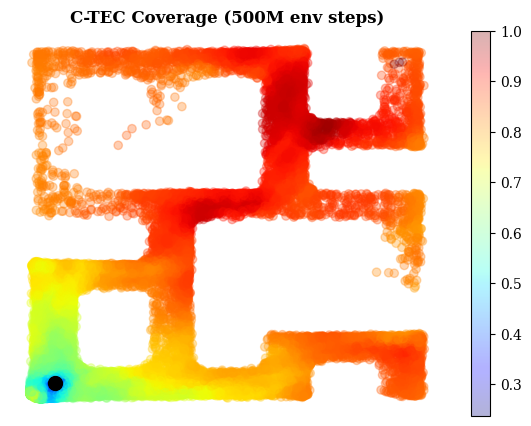

In [40]:

crl_rewards = crl_reward(model, params, obs_repeated, action, all_states, args, rng, True)
# elif "apt" in args.model:
#     obs_repeated[:,:2]
#     crl_rewards = apt_reward(model, params, all_states, action, all_states, args, rng, True)
# plot heatmap of the contrastive rewardf
rand_indices = jax.random.permutation(rng, jnp.arange(all_states.shape[0]))[:num_states]  
all_states_visual  = all_states[rand_indices, :goal_dim]
# normalize reward to range [0,1]
crl_rewards /= crl_rewards.max()
plt.figure(figsize=(7, 5))
plt.scatter(all_states_visual[:, 0], all_states_visual[:, 1], c=crl_rewards[rand_indices], cmap="jet", alpha=0.3)
plt.colorbar()
plt.scatter(obs[0], obs[1], c="black", s=100)
training_steps = args.num_timesteps//1000000
title = f"C-TEC Coverage ({training_steps}M env steps)"
fontSize = 12
plt.title(title, fontweight='bold', fontsize=fontSize)
plt.axis('off')
plt.savefig(f"maze_visuals/{title}.png", dpi=300)
plt.savefig(f"maze_visuals/{title}.pdf", dpi=300)



In [ ]:
def plot_coverage(runs_dirs, visited_states_paths):
    lenght = len(visited_states_paths)
    rng = jax.random.PRNGKey(seed)
    pick_ranodm_starting_state = False
    os.makedirs("maze_visuals", exist_ok=True)
    pick_a_goal_state=True
    use_ema = True
    fix_goal = False
    is_sim_reward = False
    compute_full_infonce_reward=False
    model_type="crl"
    for i in range(lenght):
        run_dir = runs_dirs[i]
        states_run_dir = visited_states_paths[i]
        visited_states_path = os.path.join(states_run_dir, "visited_states")
        args_filePath = os.path.join(run_dir, "args.json")
        run_dir = runs_dirs[i]
        model, params, args = extract_model(run_dir, use_ema=False)
        num_states = 100_000
        env = create_env(args)
        number_of_files = 10
        random_state=False
        all_states = jnp.array(load_visited_state(visited_states_path, number_of_files, random_state))
        rng, rng_ = jax.random.split(rng)
        num_states_reward = 100_000
        num_state_visual = 100_000
        num_states = 100_000
        state = env.reset(rng)
        rand_indices = jax.random.choice(rng, all_states.shape[0], shape=(num_states, ), replace=False)   
        all_states = all_states[rand_indices]  
        print(f"all_states.shape: {all_states.shape}")
        # pick a random observation 
        rng, rng_ = jax.random.split(rng)
        goal_dim = len(args.crl_goal_indices)
        if pick_ranodm_starting_state:
            print(jax.random.randint(rng, (1, ), 0, all_states.shape[0]))
            obs = all_states[jax.random.randint(rng_, (1, ), 0, all_states.shape[0])[0]] 
            obs = state.obs.at[:goal_dim].set(obs)
            # print(obs)
        else:
            obs = state.obs

        obs_repeated = jnp.repeat(obs[None, :args.obs_dim], all_states.shape[0], axis=0)
        # print(obs_repeated[0])
        # action = jax.random.uniform(rng_, (all_states.shape[0], args.action_dim)) 
        action = jnp.zeros((all_states.shape[0], args.action_dim))
        print(obs_repeated.shape)
        print(action.shape)
        print(all_states.shape)
        crl_rewards = crl_reward(model, params, obs_repeated, action, all_states, args, rng, True)
        # elif "apt" in args.model:
        #     obs_repeated[:,:2]
        #     crl_rewards = apt_reward(model, params, all_states, action, all_states, args, rng, True)
        # plot heatmap of the contrastive rewardf
        rand_indices = jax.random.permutation(rng, jnp.arange(all_states.shape[0]))[:num_states]  
        all_states_visual  = all_states[rand_indices, :goal_dim]
        # normalize reward to range [0,1]
        crl_rewards /= crl_rewards.max()
        plt.subplot(1, 2, i+1)
        # plt.figure(figsize=(7, 5))
        plt.scatter(all_states_visual[:, 0], all_states_visual[:, 1], c=crl_rewards[rand_indices], cmap="jet", alpha=0.3)
        plt.colorbar()
        plt.scatter(obs[0], obs[1], c="black", s=100)
        training_steps = args.num_timesteps//1000000
        title = f"C-TEC Coverage ({training_steps}M env steps)"
        fontSize = 12
        plt.title(title, fontweight='bold', fontsize=fontSize)
        plt.axis('off')
        plt.savefig(f"maze_visuals/{title}.png", dpi=300)
        plt.savefig(f"maze_visuals/{title}.pdf", dpi=300)

In [ ]:
runs_dirs = visited_states_paths = [
    "/network/scratch/f/faisal.mohamed/crl_runs/ctec_sac/ant_hardest_maze/ctec/1763060026_sandal",
#  "/network/scratch/f/faisal.mohamed/crl_runs/ctec_sac/ant_hardest_maze/ctec/1763523139_danger"
]


In [ ]:
plot_coverage(runs_dirs,visited_states_paths )

In [ ]:
from PIL import Image
import os

def combine_two_images_horizontally(path1, path2, save_path):
    # Open images
    img1 = Image.open(path1)
    img2 = Image.open(path2)

    # Ensure same height: resize second image if needed
    if img1.height != img2.height:
        img2 = img2.resize((img2.width, img1.height))

    # Calculate total width and max height
    total_width = img1.width + img2.width
    max_height = max(img1.height, img2.height)

    # Create new blank image
    new_img = Image.new('RGB', (total_width, max_height), (255,255,255))

    # Paste images
    new_img.paste(img1, (0, 0))
    new_img.paste(img2, (img1.width, 0))

    # Save combined image
    new_img.save(save_path)
    print(f"Combined image saved to {save_path}")

# Example usage:
# paths to your images
image_path1 = "maze_visuals/C-TEC Coverage (50M env steps).png"
image_path2 = "maze_visuals/C-TEC Coverage (500M env steps).png"
output_path = "maze_visuals/C-TEC Coverage (50M & 500M env steps)"

# Only combine if both exist
if os.path.exists(image_path1) and os.path.exists(image_path2):
    combine_two_images_horizontally(image_path1, image_path2, f"{output_path}.png")
    combine_two_images_horizontally(image_path1, image_path2, f"{output_path}.pdf")
else:
    print("One or both image paths do not exist.")

